### Spam/Ham Classification Model

import the basic libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset1.csv')

Gathering information about data

In [ ]:
data

,Message,Label
0,"Hi, how are you?",Ham
1,Let's meet tomorrow.,Ham
2,Call me when you reach home.,Ham
3,Good Morning! Have a nice day.,Ham
4,Can we meet at 5 PM today?,Ham
5,Please send me the assignment.,Ham
6,Happy Birthday! Have a wonderful day.,Ham
7,I'll call you later.,Ham
8,Congratulations! You won a lottery.,Spam
9,Claim your free prize now.,Spam


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Message  20 non-null     object
 1   Label    20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [ ]:
data.describe()

,Message,Label
count,20,20
unique,20,2
top,"Hi, how are you?",Ham
freq,1,10


In [ ]:
data.isnull().sum()

,0
Message,0
Label,0


Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
data['Label'] = le.fit_transform(data['Label'])

In [ ]:
data

,Message,Label
0,"Hi, how are you?",0
1,Let's meet tomorrow.,0
2,Call me when you reach home.,0
3,Good Morning! Have a nice day.,0
4,Can we meet at 5 PM today?,0
5,Please send me the assignment.,0
6,Happy Birthday! Have a wonderful day.,0
7,I'll call you later.,0
8,Congratulations! You won a lottery.,1
9,Claim your free prize now.,1


Data Splition

In [ ]:
x = data['Message']
y = data['Label']

Vectorization for converting the text data to numerical form

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(x)

In [ ]:
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 97 stored elements and shape (20, 69)>

KNN Algorithm

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)

In [ ]:
model.fit(x, y)

KNeighborsClassifier()

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Accuracy Score: ",accuracy_score(y, model.predict(x)))

Accuracy Score:  0.8


In [ ]:
print("Classification Report: \n",classification_report(y, model.predict(x)))

Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.80      0.80      0.80        10

    accuracy                           0.80        20
   macro avg       0.80      0.80      0.80        20
weighted avg       0.80      0.80      0.80        20



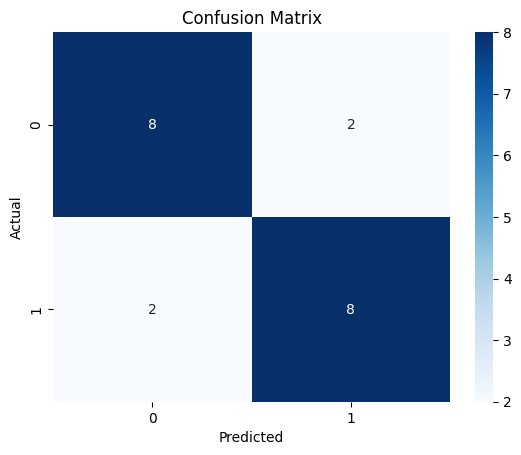

In [ ]:
cm = confusion_matrix(y, model.predict(x))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Predicting whether a message is spam or ham

In [ ]:
def predict_spam_ham(message):
    message = vectorizer.transform([message])
    prediction = model.predict(message)

    if prediction[0] == 1:
        return "Spam"
    else:
        return "Ham"

user_message = input("Enter a message to classify: ")
result = predict_spam_ham(user_message)
print(f"The message is: {result}")

Enter a message to classify: Hi,  How are you.
The message is: Ham


Model Saving

In [ ]:
import joblib

joblib.dump(model, 'spam_ham_model.h5')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


Streamlit Application

In [1]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.3 MB/s eta 0:00:00


In [2]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

model = joblib.load('spam_ham_model.h5')
vectorizer = joblib.load('vectorizer.pkl')

st.title("Spam/Ham Message Predictor")
st.write("Enter the Message to predict whether it is spam/ham: ")

msg = st.text_input("Enter the Message ")

if st.button("Predict Spam/Ham"):
  if msg:
    message = vectorizer.transform([msg])
    prediction = model.predict(message)

    if prediction[0] == 1:
        result = "Spam"
    else:
        result = "Ham"

    st.success(f"The message is: {result}")
  else:
    st.warning("Please enter a message to classify.")

Writing app.py


Launch the app

In [3]:
from pyngrok import ngrok
from google.colab import userdata
import time

NGROK_AUTH_TOKEN = userdata.get('SPAM_NGROK_AUTH_TOKEN')

if not NGROK_AUTH_TOKEN:
    print("Error: SPAM_NGROK_AUTH_TOKEN not found in Colab Secrets.")
    print("Please add your ngrok authtoken to Colab's 'Secrets' manager.")
else:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)

    try:
        tunnels = ngrok.get_tunnels()
        for tunnel in tunnels:
            print(f"Disconnecting existing tunnel: {tunnel.public_url}")
            ngrok.disconnect(tunnel.public_url)
    except Exception as e:
        print(f"Could not disconnect existing tunnels (this might be normal if none were active): {e}")

    ngrok.kill()
    time.sleep(2)

    !streamlit run app.py&>/dev/null&

    time.sleep(5)

    try:
        public_url = ngrok.connect(addr='8501', proto='http')
        print(f"Your Streamlit app is live at: {public_url}")
    except Exception as e:
        print(f"An error occurred while connecting to ngrok: {e}")
        print("This typically happens if a previous ngrok tunnel is still active or Streamlit failed to start.")
        print("If the issue persists, try restarting the Colab runtime (Runtime -> Restart runtime) and rerunning this cell.")

Your Streamlit app is live at: NgrokTunnel: "https://doorbell-illusion-maverick.ngrok-free.dev" -> "http://localhost:8501"
